In [1]:
from onep import paths
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline

In [2]:
# Load your exported CSV
df = pd.read_csv(paths.processed("supplementary", "ihc", "IHC_Counts.csv"))
df

,Stain,Mouse,Specificity
0,NeuN,F8,0.647
1,NeuN,F10,0.000
2,NeuN,F6,0.289
3,NeuN,M6,0.000
4,GFAP,F6,99.598
5,GFAP,F3,100.000
6,GFAP,M5,100.000
7,GFAP,F5,100.000
8,GFAP,M7,99.740


In [3]:
import numpy as np
eps = 1e-6
p = (df["Specificity"] / 100.0).clip(eps, 1 - eps)
df["pct_logit"] = np.log(p / (1 - p))

In [4]:
df

,Stain,Mouse,Specificity,pct_logit
0,NeuN,F8,0.647,-5.034088
1,NeuN,F10,0.000,-13.815510
2,NeuN,F6,0.289,-5.843605
3,NeuN,M6,0.000,-13.815510
4,GFAP,F6,99.598,5.512445
5,GFAP,F3,100.000,13.815510
6,GFAP,M5,100.000,13.815510
7,GFAP,F5,100.000,13.815510
8,GFAP,M7,99.740,5.949640


In [5]:
def plot_avg_specificity(df, title="", save_path=None):
    sns.set(style="ticks", font="Arial")
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(2, 3), dpi=600)

    # Barplot — assign color list manually using palette override
    sns.barplot(
        x='Stain', y='Specificity', data=df,
         ci=68, capsize=.2, errwidth=1,
        alpha=0.8, ax=ax
    )

    # Stripplot — black dots on top of each bar
    sns.stripplot(
        x='Stain', y='Specificity', data=df,
        jitter=True, linewidth=0.3, edgecolor='black',
        size=4, ax=ax
    )

    ax.legend_.remove() if ax.legend_ else None
    ax.set_ylabel('Specificity (% Stain/GCaMP+)', fontsize=10)
    ax.set_xlabel('', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(-1, 105)
    ax.set_title(title, fontsize=10, pad=10)
    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax

C:\Users\ryansenne\AppData\Local\Temp\ipykernel_41616\2149307336.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(
C:\Users\ryansenne\AppData\Local\Temp\ipykernel_41616\2149307336.py:8: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(


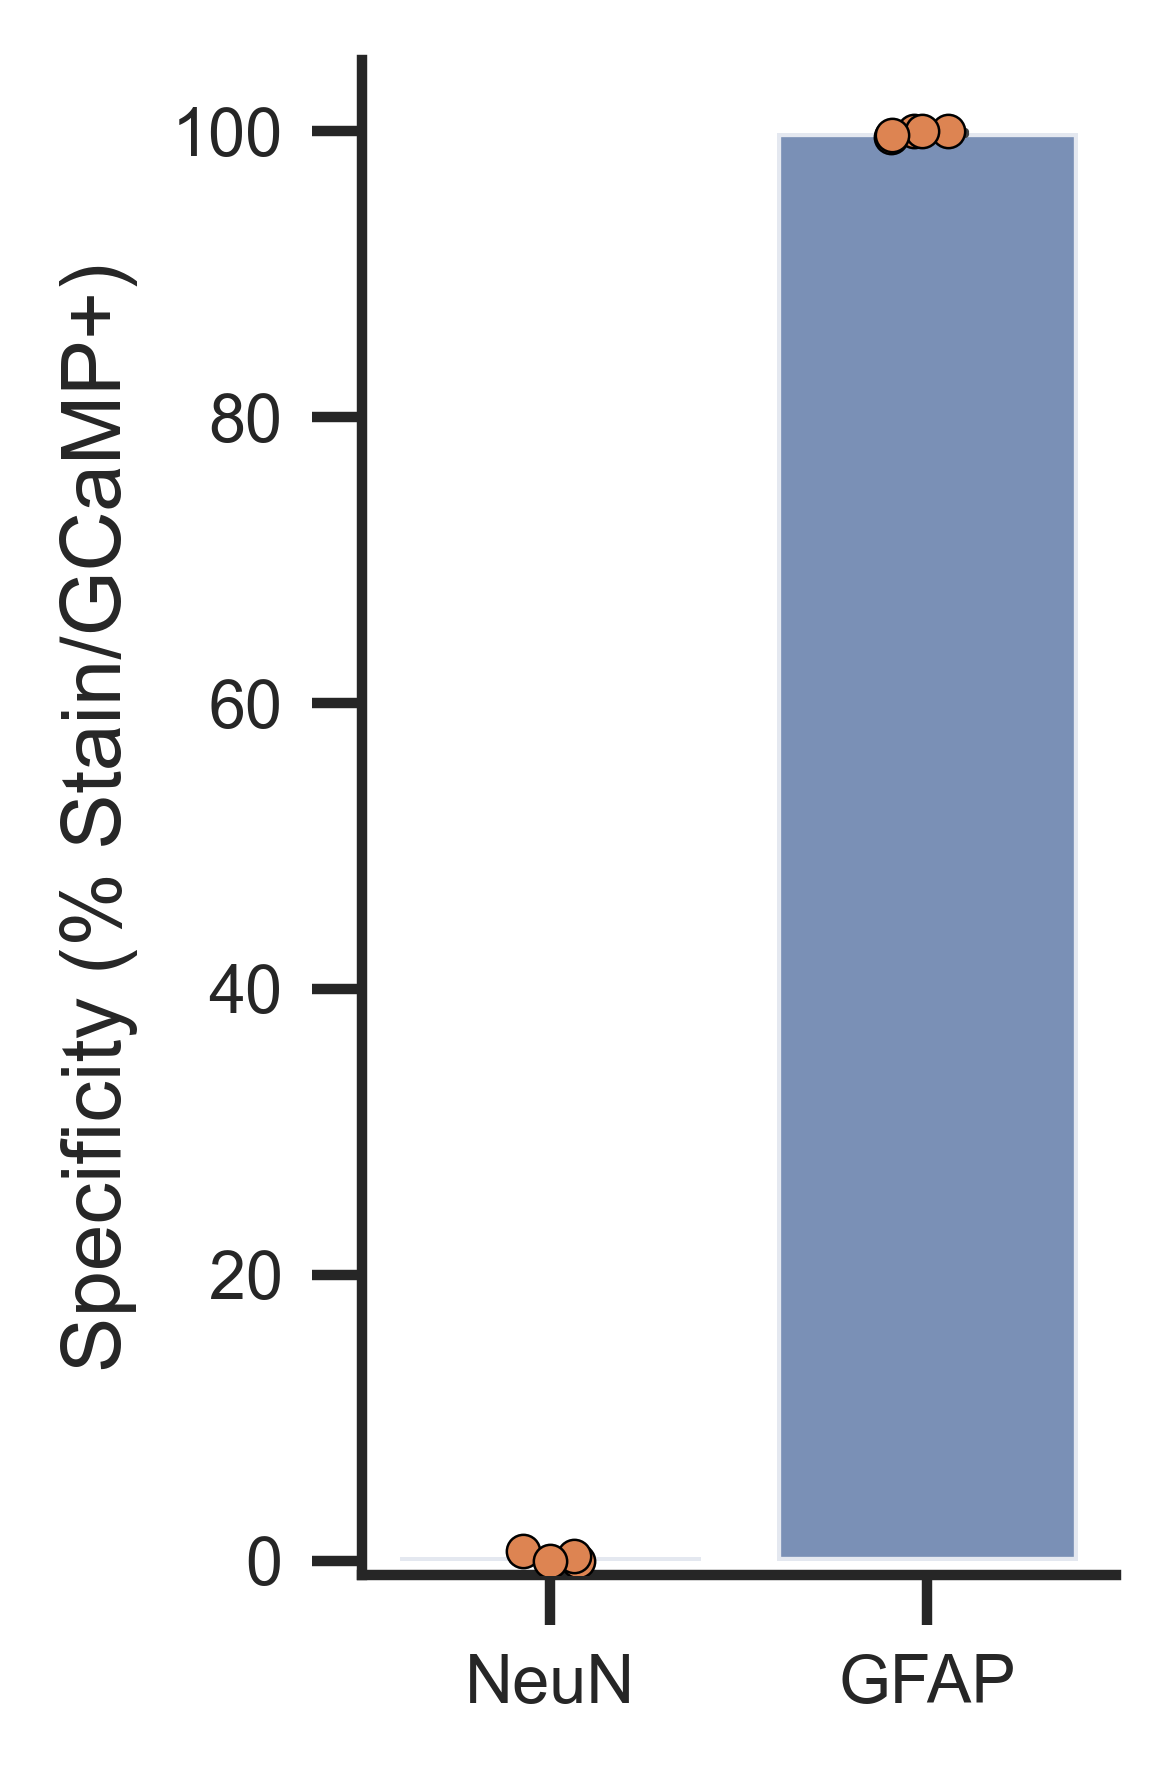

(<Figure size 1200x1800 with 1 Axes>,
 <Axes: ylabel='Specificity (% Stain/GCaMP+)'>)

In [6]:
plot_avg_specificity(df,save_path=paths.figure_path("supplementary", "IHC_Specificity_Barplot.svg") )